# GPT Evaluation Notebook V3 [![DOI](https://zenodo.org/badge/660157642.svg)](https://zenodo.org/badge/latestdoi/660157642)
![Notes on (Computational) Social Media Research Banner](https://raw.githubusercontent.com/michaelachmann/social-media-lab/main/images/banner.png)

## Overview

This Jupyter notebook is a part of the social-media-lab.net project, which is a work-in-progress textbook on computational social media analysis. The notebook is intended for use in my classes.

The **GPT Evaluation V3** Notebook helps to calculate interrater agreement scores like Cohen's Kappa and Krippendorff's Alpha for a combination of human annotations (exported from [Label Studio](https://labelstud.io/) and GPT- (or other ML/LLM) based annotations. Version two handles multiple JSON files as input, compatible with the open source version of LabelStudio.

### Project Information

- Project Website: [social-media-lab.net](https://social-media-lab.net/)
- GitHub Repository: [https://github.com/michaelachmann/social-media-lab](https://github.com/michaelachmann/social-media-lab)

## License Information

This notebook, along with all other notebooks in the project, is licensed under the following terms:

- License: [GNU General Public License version 3.0 (GPL-3.0)](https://www.gnu.org/licenses/gpl-3.0.de.html)
- License File: [LICENSE.md](https://github.com/michaelachmann/social-media-lab/blob/main/LICENSE.md)


## Citation

If you use or reference this notebook in your work, please cite it appropriately. Here is an example of the citation:

```
Michael Achmann. (2024). michaelachmann/social-media-lab: 2024-12-9 (v0.0.15). Zenodo. https://doi.org/10.5281/zenodo.8199902
```

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# @title Read the LabelStudio Annotations from file
# @markdown <p><b>NEW</b> This version deals with multiple annotation projects. The community version of Label Studio does not handle more than one annotator per item. Setup three different projects using the same data and have one annotator use one project. Export the results and add the files to the list below. The python loop creates one annotation dataset from the three annotations projects and provides all interrater reliability measures as with previous versions of this notebook.<p>
# @markdown <p><b>NEW</b> This version handles `labels` for the annotation of bounding boxes in images.</p>
# @markdown <p><b>NOTE</b> This version does not handle reviews!</p>
# @markdown <hr />

# @markdown Please select the project type. Choose *Single* for a single annotation project, or Multi, to manually join three annotation projects (Label Studio Open Source).
project_type = "Multi" # @param ["Multi", "Single"] {allow-input: true}

# @markdown <hr />


single_annotation_project = '' # @param {type: "string"}

# @markdown <hr />


annotation_project_1 = '/content/drive/MyDrive/Forschungsseminar_Computergestützte_Analyse_Sozialer_Medien/Daten/Auswertung/1_project-172-merged.json' # @param {type: "string"}
annotation_project_2 = '/content/drive/MyDrive/Forschungsseminar_Computergestützte_Analyse_Sozialer_Medien/Daten/Auswertung/2_project-174-merged.json' # @param {type: "string"}
annotation_project_3 = '/content/drive/MyDrive/Forschungsseminar_Computergestützte_Analyse_Sozialer_Medien/Daten/Auswertung/3_project-175-merged.json' # @param {type: "string"}

if project_type == "Single":
  human_annotations_jsons = [single_annotation_project]
else:
  human_annotations_jsons = [annotation_project_1, annotation_project_2, annotation_project_3]

import json
import pandas as pd
from tqdm.notebook import tqdm

exported_annotations = []

for human_annotations_json in human_annotations_jsons:
  with open(human_annotations_json, 'r') as f:
    j = f.read()
    exported_annotations.append(json.loads(j))



def process_result(result, coder, md):
    value_type = result.get('type', "")
    metadata = {
        **md,
        "coder": coder,
        "from_name": result.get('from_name', "")
    }
    annotations = []
    if value_type == "choices":
        choices = result['value'].get('choices', [])
        for choice in choices:
            r = {**metadata}
            r['value'] = choice
            annotations.append(r)
    elif value_type == "taxonomy":
        taxonomies = result['value'].get('taxonomy', [])
        for taxonomy in taxonomies:
            if len(taxonomy) > 1:
                taxonomy = " > ".join(taxonomy)
            elif len(taxonomy) == 1:
                taxonomy = taxonomy[0]
            r = {**metadata}
            r['value'] = taxonomy
            annotations.append(r)
    elif value_type == "labels":
        labels = result['value'].get('labels', [])
        labels_id = result.get('id', '')
        label = "".join(labels)
        r = {**metadata}
        r['value'] = label
        r['id'] = labels_id
        annotations.append(r)

    return annotations

all_annotations = []
for exported_annotation in tqdm(exported_annotations):
  for data in tqdm(exported_annotation):
      annotations = data.get("annotations")
      metadata = {
          **data.get("data")
      }

      for annotation in annotations:
        coder_data = annotation['completed_by']
        if isinstance(coder_data, dict):
            coder = coder_data.get('id', coder_data)
        else:
            coder = coder_data

        results = annotation.get("result")
        if results:
          for result in results:
            all_annotations.extend(process_result(result, coder, metadata))
        else:
          print("Skipped Missing Result")


all_annotations_df = pd.DataFrame(all_annotations)

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/459 [00:00<?, ?it/s]

Skipped Missing Result
Skipped Missing Result


  0%|          | 0/459 [00:00<?, ?it/s]

  0%|          | 0/459 [00:00<?, ?it/s]

Skipped Missing Result
Skipped Missing Result


In [ ]:
# Check the dataframe
all_annotations_df.head()

,image,Unnamed: 0,thread_id,parent_id,body,author,author_fullname,author_avatar_url,timestamp,type,...,num_comments,num_media,unix_timestamp,country,coder,from_name,value,hashtags,location_name,location_latlong
0,/data/upload/172/523f87ef-DSiKM6WEVCz.jpg,279,DSiKM6WEVCz,DSiKM6WEVCz,to nap or not to nap?💤,naraaziza,Nara Smith,https://scontent-ham3-1.cdninstagram.com/v/t51...,12/21/25 17:23,photo,...,955,3,1766337787,usa,54,classification,Inside,NaN,NaN,NaN
1,/data/upload/172/e286c046-DRPukA1EQce.jpg,291,DRPukA1EQce,DRPukA1EQce,All black or color for the @aritzia Flatiron F...,naraaziza,Nara Smith,https://scontent-ham3-1.cdninstagram.com/v/t51...,11/19/25 17:03,photo,...,507,2,1763571832,usa,54,classification,Inside,aritziapartner,NaN,NaN
2,/data/upload/172/1c96ff64-DQMqoqgkR2s.jpg,301,DQMqoqgkR2s,DQMqoqgkR2s,first night out @mango #craftyourownstory #inp...,naraaziza,Nara Smith,https://scontent-ham3-1.cdninstagram.com/v/t51...,10/24/25 16:00,mixed,...,520,3,1761321626,usa,54,classification,Inside,"craftyourownstory,inpaidpartnership",NaN,NaN
3,/data/upload/172/fbe2702f-DUoC5HZEf9u.jpg,266,DUoC5HZEf9u,DUoC5HZEf9u,how is everyone feeling 1-5? life has felt ove...,naraaziza,Nara Smith,https://scontent-ham3-1.cdninstagram.com/v/t51...,2/11/26 17:17,mixed,...,395,8,1770830248,usa,54,classification,Inside,NaN,NaN,NaN
4,/data/upload/172/2cca12c4-DP6imYIEZla.jpg,304,DP6imYIEZla,DP6imYIEZla,my recent camera roll! 🫧 life has been magical...,naraaziza,Nara Smith,https://scontent-ham3-1.cdninstagram.com/v/t51...,10/17/25 15:03,mixed,...,1124,8,1760713434,usa,54,classification,Inside,NaN,NaN,NaN


## Contingency Table

We select one coding in this step (e.g. Positioning) and create a contingency table where each annotated item (text, image) occupies one row and each coder one column. The `identifier` should be set to a unique column, like `uuid` or `Filename`.

In [ ]:
# @markdown  Enter the `from_name` for the variable you're interested in at the moment. (Refer to your LabelStudio Interface for the right `from_name`).

import pandas as pd
import numpy as np

from_name = 'classification' # @param {type:"string"}
identifier = 'thread_id' # @param {type:"string"}

# Assuming your DataFrame is named 'df'
filtered_df = all_annotations_df[all_annotations_df['from_name'].str.contains(from_name, case=False)]

def to_bool(val):
  if isinstance(val, bool):
    return val
  if isinstance(val, str):
    return val.lower() == "true"

  return bool(val)

values = filtered_df['value'].unique()
identifier_values = filtered_df[identifier].unique()

contingency_matrix = pd.crosstab(filtered_df[identifier], filtered_df['coder'], values=filtered_df['value'], aggfunc='first')
contingency_matrix = contingency_matrix.reindex(identifier_values)

In [ ]:
# Let's take a look at the contigency table. We refer to each coder using a pseudonymous number.
contingency_matrix.head()

coder,39,54,55
thread_id,,,
DSiKM6WEVCz,Inside,Inside,Inside
DRPukA1EQce,Inside,Inside,Unsure
DQMqoqgkR2s,Inside,Inside,Inside
DUoC5HZEf9u,Inside,Inside,Inside
DP6imYIEZla,Inside,Inside,Inside


## Let's filter: Only rows with min. 3 Annotations

In [ ]:
n_annot = contingency_matrix.notna().sum(axis=1)          # count non-NaN per row/image
contingency_matrix  = contingency_matrix.loc[n_annot > 2]             # keep images with < 3 annotations


### Calculate Pairwise $\kappa$

Let's calculate Cohen's Kappa for each coder pair.

In [ ]:
from sklearn.metrics import cohen_kappa_score

# Function to calculate Cohen's Kappa for each pair of raters
def calculate_kappa(matrix):
    raters = matrix.columns
    kappa_scores = []
    for i in range(len(raters)):
        for j in range(i+1, len(raters)):
            rater1, rater2 = raters[i], raters[j]
            # Drop NA values for the pair of raters
            pair_matrix = matrix[[rater1, rater2]].dropna()
            # Skip pairs without overlaps
            if len(pair_matrix) > 0:
              kappa = cohen_kappa_score(pair_matrix[rater1], pair_matrix[rater2])
              kappa_scores.append({
                  "Coder 1": rater1,
                  "Coder 2": rater2,
                  "Kappa": kappa,
                  "Overlap": len(pair_matrix),
                  "Coding": from_name
                  })
    return kappa_scores

kappa_scores = calculate_kappa(contingency_matrix)
kappa_scores_df = pd.DataFrame(kappa_scores)

In [ ]:
# Let's display the pairwise Kappa agreements.
kappa_scores_df

,Coder 1,Coder 2,Kappa,Overlap,Coding
0,39,54,0.791826,455,classification
1,39,55,0.799269,455,classification
2,54,55,0.840930,455,classification


### Overall Agreement: Krippendorff's $\alpha$

Next, we calculate the overall agreement using Krippendorffs Alpha. First we need to install the package.

In [ ]:
!pip install krippendorff

In [ ]:
import krippendorff
import pandas as pd

def convert_to_reliability_data(matrix):
    transposed_matrix = matrix.T
    reliability_data = []
    for _, ratings in transposed_matrix.iterrows():
        reliability_data.append(ratings.tolist())
    return reliability_data

reliability_data = convert_to_reliability_data(contingency_matrix)

# Calculating Krippendorff's Alpha treating "Unsure" as a distinct category
alpha = krippendorff.alpha(reliability_data=reliability_data, level_of_measurement='nominal')

print("Krippendorff's Alpha:", alpha)

Krippendorff's Alpha: 0.810434444228257


## Majority Decision

One approach to assess the quality of machine labelled data is the comparison between machine-generated labels and human-generated labels, commonly known as "gold standard" labels. This process is called "label agreement" or "inter-rater agreement" and is widely used in various fields, including natural language processing, machine learning, and computational social science.

We are going to use create a `majority_decision` column using the human annotations: We have chosen an uneven number of annotators in order to find a majority for each label. First, we are going to create a contingency table (or matrix), then we can determine the majority decision.

In [ ]:
def get_majority_decision(row):
    counts = row.value_counts()
    total = row.notna().sum()

    if total < 2:
        return np.nan  # insufficient data

    top_value = counts.index[0]
    top_count = counts.iloc[0]

    # Check for ties
    if len(counts) > 1 and counts.iloc[0] == counts.iloc[1]:
        return np.nan  # tie, no clear majority

    # Optional: require strict majority (>50%)
    # if top_count <= total / 2:
    #     return np.nan

    return top_value

contingency_matrix['Majority Decision'] = contingency_matrix.apply(get_majority_decision, axis=1)

In [ ]:
contingency_matrix.head()

coder,39,54,55,Majority Decision
thread_id,,,,
DSiKM6WEVCz,Inside,Inside,Inside,Inside
DRPukA1EQce,Inside,Inside,Unsure,Inside
DQMqoqgkR2s,Inside,Inside,Inside,Inside
DUoC5HZEf9u,Inside,Inside,Inside,Inside
DP6imYIEZla,Inside,Inside,Inside,Inside


In [ ]:
contingency_matrix['Majority Decision'].value_counts()

,count
Majority Decision,
Inside,211
Outside,122
NotApplicable,105
Unsure,11


## Export Annotations

In [ ]:
country_mapping = all_annotations_df[['thread_id', 'country']].drop_duplicates().set_index('thread_id')
export_df = contingency_matrix.reset_index().merge(country_mapping, on='thread_id', how='left')
export_df[['thread_id', 'Majority Decision', 'country']].to_csv('/content/drive/MyDrive/Forschungsseminar_Computergestützte_Analyse_Sozialer_Medien/Daten/Auswertung/export_annotations.csv', index=False)

In [ ]:
# @title Import computational annotations
# @markdown Reading the GPT annotations. Enter the correct file path below

import pandas as pd
import numpy as np

annotated_file = '/content/drive/MyDrive/Forschungsseminar_Computergestützte_Analyse_Sozialer_Medien/Daten/Auswertung/GPT5-mini-Test-Set.csv' # @param {type:"string"}
coding_column = 'GPT-5-mini' # @param {type:"string"}
annotated_identifier = 'thread_id' # @param {type:"string"}

annotated_df = pd.read_csv(annotated_file)

In [ ]:
annotated_df.head()

,thread_id,label,country,image,GPT-5-mini,Explanation
0,DPNrGbpEdDn,Outside,usa,/content/drive/MyDrive/Forschungsseminar_Compu...,Outside,"Open sky, hillside, vegetation, raised garden ..."
1,CW8r5WQtSvb,Outside,germany,/content/drive/MyDrive/Forschungsseminar_Compu...,Outside,"Visible open sky, trees, and a large monument ..."
2,CWYjX3kL2MI,Outside,germany,/content/drive/MyDrive/Forschungsseminar_Compu...,Outside,"Open natural landscape with visible sky, grass..."
3,Cjgwbdasffh,Outside,usa,/content/drive/MyDrive/Forschungsseminar_Compu...,Outside,"Visible trees, sky, outdoor lantern, and surro..."
4,DQWtJrGERvz,Inside,usa,/content/drive/MyDrive/Forschungsseminar_Compu...,Inside,The scene clearly shows a kitchen interior wit...


In [ ]:
contingency_table = pd.merge(contingency_matrix, annotated_df[['thread_id', coding_column]], left_on=identifier, right_on=annotated_identifier, how='left')
contingency_table.rename(columns={coding_column: "Model"}, inplace=True)

In [ ]:
contingency_table.head()

,thread_id,39,54,55,Majority Decision,Model
0,DSiKM6WEVCz,Inside,Inside,Inside,Inside,NaN
1,DRPukA1EQce,Inside,Inside,Unsure,Inside,NaN
2,DQMqoqgkR2s,Inside,Inside,Inside,Inside,NaN
3,DUoC5HZEf9u,Inside,Inside,Inside,Inside,Inside
4,DP6imYIEZla,Inside,Inside,Inside,Inside,NaN


Let's suppose we're dealing with binary data. We convert all value to binary, in order to be able to compare them correctly.

In [ ]:
# Function to convert a column to boolean if it's not already
def convert_to_bool(column):
    # The original intent here was to convert to boolean, but the current labels are categorical.
    # For calculating Cohen's Kappa on multi-class labels, direct conversion to 'True'/'False'
    # is not always appropriate or necessary. If a binary comparison is strictly needed (e.g.,
    # 'Inside' vs. 'Not Inside'), the mapping logic would need to be more specific.
    # For now, we will skip this conversion to allow kappa to be calculated on the original categories.
    return contingency_table[column]

# Convert columns to boolean if they are not already
# By returning the column as is from convert_to_bool, we effectively bypass the boolean conversion
contingency_table['Majority Decision']= convert_to_bool('Majority Decision')
contingency_table['Model'] = convert_to_bool('Model')

Let's quickly check pairwise agreement between the Model and Majority Decision using Cohen's Kappa:

In [ ]:
kappa_scores = calculate_kappa(contingency_table[['Majority Decision', 'Model']])
pd.DataFrame(kappa_scores).head()

,Coder 1,Coder 2,Kappa,Overlap,Coding
0,Majority Decision,Model,0.814932,88,classification


## Machine Learning Metrics

Finally, let's calculate Accuracy, Precision, and F1 Score and plot a confusion matrix.

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from IPython.display import display, Markdown
import numpy as np


# Filter out rows where either 'Majority Decision' or 'Model' is NaN
filtered_contingency_table = contingency_table.dropna(subset=['Majority Decision', 'Model']).copy()

# Ensure that the data types are consistent (all strings)
filtered_contingency_table['Majority Decision'] = filtered_contingency_table['Majority Decision'].astype(str)
filtered_contingency_table['Model'] = filtered_contingency_table['Model'].astype(str)

# Check if the filtered table is empty
if filtered_contingency_table.empty:
    print("No overlapping non-NaN data for 'Majority Decision' and 'Model' to calculate metrics.")
else:
    # Calculating metrics for multi-class classification
    # For multi-class, 'average' parameter should be set to 'macro', 'micro', 'weighted', or None
    # Using 'weighted' to account for label imbalance
    accuracy = accuracy_score(filtered_contingency_table['Majority Decision'], filtered_contingency_table['Model'])
    precision = precision_score(filtered_contingency_table['Majority Decision'], filtered_contingency_table['Model'], average='weighted', zero_division=0)
    recall = recall_score(filtered_contingency_table['Majority Decision'], filtered_contingency_table['Model'], average='weighted', zero_division=0)
    f1 = f1_score(filtered_contingency_table['Majority Decision'], filtered_contingency_table['Model'], average='weighted', zero_division=0)

    # Creating a DataFrame for the metrics
    metrics_df = pd.DataFrame({
        'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
        'Value': [accuracy, precision, recall, f1]
    })

    # Displaying the DataFrame as a table
    display(metrics_df)

,Metric,Value
0,Accuracy,0.886364
1,Precision,0.901380
2,Recall,0.886364
3,F1 Score,0.872632


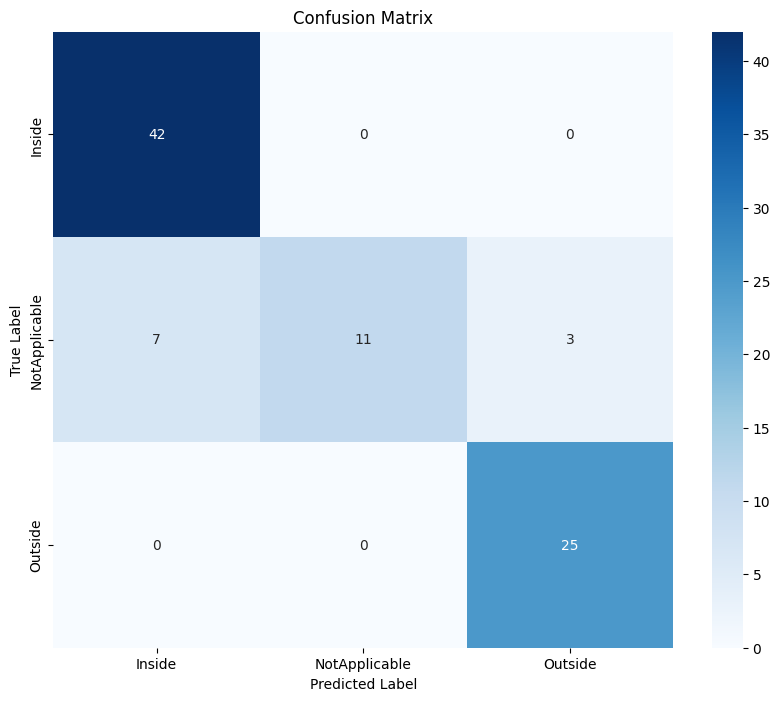

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Ensure filtered_contingency_table is available and populated from the previous cell
# Re-filtering here in case this cell is run independently, or if previous cell was skipped
if 'filtered_contingency_table' not in locals() or filtered_contingency_table.empty:
    filtered_contingency_table = contingency_table.dropna(subset=['Majority Decision', 'Model']).copy()
    filtered_contingency_table['Majority Decision'] = filtered_contingency_table['Majority Decision'].astype(str)
    filtered_contingency_table['Model'] = filtered_contingency_table['Model'].astype(str)

# Check if the filtered table is still empty after re-filtering
if filtered_contingency_table.empty:
    print("Cannot plot confusion matrix: No overlapping non-NaN data for 'Majority Decision' and 'Model'.")
else:
    # Get unique labels from both 'Majority Decision' and 'Model' columns
    labels = np.unique(filtered_contingency_table[['Majority Decision', 'Model']].values)
    labels = np.sort(labels) # Sort labels for consistent plotting

    # Generate the confusion matrix
    cm = confusion_matrix(filtered_contingency_table['Majority Decision'], filtered_contingency_table['Model'], labels=labels)

    # Plotting the confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()